In [5]:
import pandas as pd
from sklearn.linear_model import LinearRegression,Lasso,Ridge,LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score,classification_report,confusion_matrix,accuracy_score
import numpy as np
from matplotlib import pyplot as plt
from sklearn.preprocessing import PolynomialFeatures,StandardScaler,MinMaxScaler
import seaborn as sns
import re
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB,GaussianNB
from nltk.corpus import stopwords
from nltk.tokenize import sent_tokenize,word_tokenize,wordpunct_tokenize,TreebankWordTokenizer
from nltk.stem import WordNetLemmatizer
from gensim.utils import simple_preprocess
import string as st

In [6]:
df=pd.read_csv('YoutubeCommentsDataSet.csv')

In [7]:
df.head()

,Comment,Sentiment
0,lets not forget that apple pay in 2014 require...,neutral
1,here in nz 50 of retailers don’t even have con...,negative
2,i will forever acknowledge this channel with t...,positive
3,whenever i go to a place that doesn’t take app...,negative
4,apple pay is so convenient secure and easy to ...,positive


In [8]:
df.shape

(18408, 2)

In [9]:
df.isnull().sum()

Comment      44
Sentiment     0
dtype: int64

In [10]:
df=df.dropna()

In [11]:
df.shape

(18364, 2)

In [12]:
df.duplicated().sum()

np.int64(490)

In [13]:
df=df.drop_duplicates()

In [14]:
df.shape

(17874, 2)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17874 entries, 0 to 18407
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Comment    17874 non-null  object
 1   Sentiment  17874 non-null  object
dtypes: object(2)
memory usage: 418.9+ KB


In [16]:
df.Sentiment.value_counts()

Sentiment
positive    11054
neutral      4503
negative     2317
Name: count, dtype: int64

<Axes: xlabel='Sentiment'>

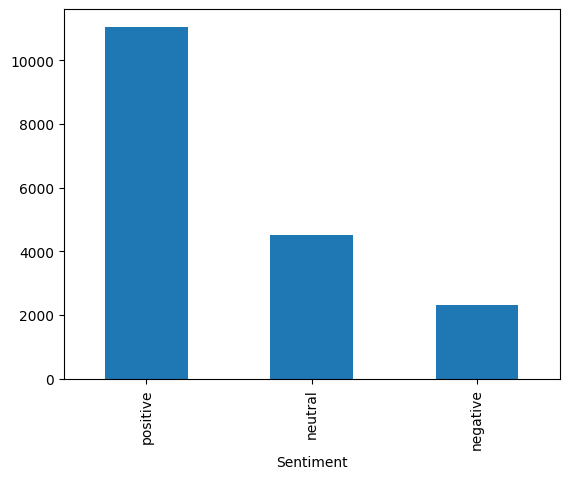

In [17]:
df.Sentiment.value_counts().plot(kind='bar')

In [18]:
punctuations=st.punctuation
punctuations

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [19]:
df['Comment'].head()

0    lets not forget that apple pay in 2014 require...
1    here in nz 50 of retailers don’t even have con...
2    i will forever acknowledge this channel with t...
3    whenever i go to a place that doesn’t take app...
4    apple pay is so convenient secure and easy to ...
Name: Comment, dtype: object

In [20]:
df['Comment']=df['Comment'].str.translate(str.maketrans('','',punctuations))

In [21]:
x_train,x_test,y_train,y_test=train_test_split(df.Comment,df.Sentiment,test_size=0.2,random_state=42)

CountVectorizer

In [22]:
cv=CountVectorizer(stop_words='english')

In [23]:
x_train_count=cv.fit_transform(x_train)
x_test_count=cv.transform(x_test)

In [24]:
x_train_count=x_train_count.toarray()
x_test_count=x_test_count.toarray()

In [25]:
model=MultinomialNB()

In [26]:
model.fit(x_train_count,y_train)

MultinomialNB()

In [27]:
y_pred=model.predict(x_test_count)

In [28]:
cr=classification_report(y_test,y_pred)
print(cr)

              precision    recall  f1-score   support

    negative       0.63      0.30      0.40       456
     neutral       0.73      0.33      0.46       906
    positive       0.72      0.95      0.82      2213

    accuracy                           0.71      3575
   macro avg       0.69      0.53      0.56      3575
weighted avg       0.71      0.71      0.67      3575



In [29]:
cm=confusion_matrix(y_test,y_pred)
cm

array([[ 135,   25,  296],
       [  64,  303,  539],
       [  15,   86, 2112]])

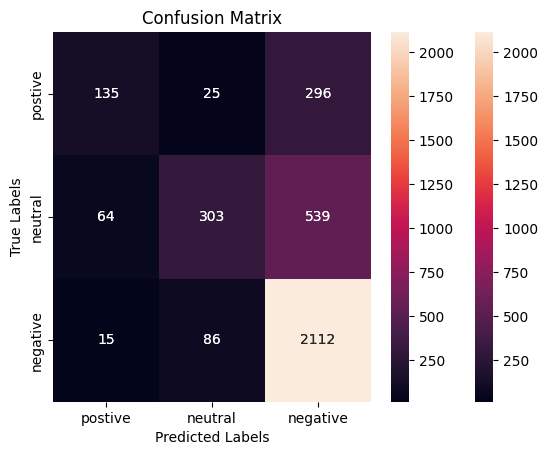

In [30]:
sns.heatmap(cm,annot=True,fmt='d')
classes = ["postive","neutral","negative"]

sns.heatmap(cm, annot=True,fmt="d",xticklabels=classes, yticklabels=classes)   
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [31]:
comments = [
    'lets not forget that apple pay in 2014 required a brand new iphone in order to use it a significant portion of apples user base wasnt able to use it even if they wanted to as each successive iphone incorporated the technology and older iphones were replaced the number of people who could use the technology increased',
    'apple pay is so convenient secure and easy to use i used it while at the korean and japanese airports no need for physical credit cards',
    'for now i need both apple pay and the physical credit card',
    'linus this is not a table also linus lets use this as a chair',
    'liquid nitrogen à´‡à´¤àµà´µà´°àµ† à´¤àµ€àµ¼à´¨àµà´¨à´¿à´²àµà´²àµ‡ à´®à´šàµà´šà´¾à´¨àµ†',
    'this series is exactly what career day shouldve been such interesting and knowledgeable people',
    'my name is vrishank'
]
comments_count = cv.transform(comments)
model.predict(comments_count)

array(['positive', 'positive', 'positive', 'positive', 'positive',
       'positive', 'positive'], dtype='<U8')

TFIDF

In [32]:
tf=TfidfVectorizer()

In [33]:
x_train_count=tf.fit_transform(x_train)
x_test_count=tf.transform(x_test)

In [34]:
x_train_count=x_train_count.toarray()
x_test_count=x_test_count.toarray()

In [35]:
model.fit(x_train_count,y_train)

MultinomialNB()

In [36]:
y_pred=model.predict(x_test_count)

In [37]:
cr=classification_report(y_test,y_pred)
print(cr)

              precision    recall  f1-score   support

    negative       0.00      0.00      0.00       456
     neutral       0.77      0.20      0.31       906
    positive       0.65      0.98      0.78      2213

    accuracy                           0.66      3575
   macro avg       0.47      0.39      0.36      3575
weighted avg       0.60      0.66      0.56      3575



c:\Users\VRISHANK\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\VRISHANK\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\VRISHANK\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [38]:
cm=confusion_matrix(y_test,y_pred)
cm

array([[   0,    3,  453],
       [   0,  178,  728],
       [   0,   49, 2164]])

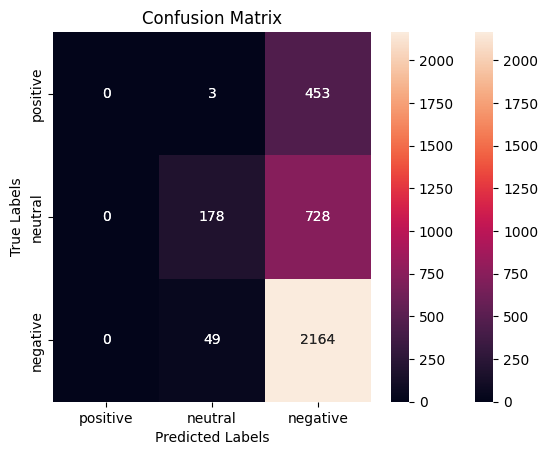

In [39]:
sns.heatmap(cm,annot=True,fmt='d')
classes = ["positive","neutral","negative"]

sns.heatmap(cm, annot=True,fmt="d",xticklabels=classes, yticklabels=classes)   
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()